## Tourism Experience Analytics: Classification, Prediction & Recommendation System





## Project Summary

**Tourism Experience Analytics: Classification, Prediction, and Recommendation System**

Tourism Experience Analytics is a data-driven Machine Learning project designed to analyze tourist behavior, predict user preferences, and provide personalized attraction recommendations. The project uses a Tourism Dataset containing transaction, user, city, attraction, country, region, continent, and visit-mode information. The main objective is to improve tourism experiences by combining Data Analytics, Machine Learning, and recommendation techniques.

The project begins with data cleaning and preprocessing, including handling missing values, resolving inconsistencies, standardizing data formats, encoding categorical variables, and combining information from multiple datasets. Exploratory Data Analysis (EDA) is performed to understand tourism trends, user demographics, popular attractions, ratings, regions, and visit patterns. Data visualization is used to identify relationships, trends, and important insights.

The system performs three major tasks. First, a **regression model** predicts the rating a user may give to a tourist attraction based on user demographics, visit details, and attraction characteristics. Second, a **classification model** predicts the user's likely visit mode, such as Business, Family, Couples, or Friends. Models such as Random Forest, LightGBM, or XGBoost can be used for classification. Third, a **recommendation system** suggests attractions based on users' previous visits, ratings, preferences, and attraction characteristics using collaborative or content-based filtering.

The project also includes a **Streamlit application** where users can enter their details and receive visit-mode predictions and personalized attraction recommendations. The final system provides actionable tourism insights that can support personalized services, targeted marketing, and improved customer engagement.


## Problem Statement

### Problem Statement

Tourism agencies and travel platforms generate large amounts of data related to user preferences, travel patterns, attraction visits, ratings, demographics, and visit modes. However, this data is often not effectively utilized to understand user behavior and provide personalized tourism experiences. Users may find it difficult to discover attractions that match their interests, while tourism businesses may lack sufficient insights to understand customer preferences, popular attractions, and travel patterns.

The proposed **Tourism Experience Analytics** project aims to address these challenges using Data Analytics and Machine Learning techniques. The system analyzes user and attraction data to perform three major tasks: predicting attraction ratings, classifying the likely visit mode of users, and recommending personalized tourist attractions. It uses historical visit information, user demographics, attraction characteristics, and ratings to identify meaningful patterns and generate useful predictions. The project also provides actionable insights that can help tourism businesses improve customer experience, support targeted marketing, and increase customer engagement and retention through personalized recommendations.


In [1]:
# ============================================================
# TOURISM EXPERIENCE ANALYTICS
# RAM-SAFE VERSION
# ============================================================

!pip -q install catboost xgboost openpyxl joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.9 MB/s eta 0:00:00


In [2]:
# ============================================================
# DATASET PATH
# ============================================================

ZIP_PATH = "/content/Tourism Dataset-20260921T103614Z-1-001.zip"

print("Dataset:", ZIP_PATH)

Dataset: /content/Tourism Dataset-20260921T103614Z-1-001.zip


In [3]:
# ============================================================
# EXTRACT DATASET
# ============================================================

import os
import zipfile
import shutil

EXTRACT_DIR = "/content/tourism_data"

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

os.makedirs(EXTRACT_DIR)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("Dataset extracted successfully.")

for root, dirs, files in os.walk(EXTRACT_DIR):
    for file in files:
        print(os.path.join(root, file))

Dataset extracted successfully.
/content/tourism_data/Tourism Dataset/Transaction.xlsx
/content/tourism_data/Tourism Dataset/Country.xlsx
/content/tourism_data/Tourism Dataset/User.xlsx
/content/tourism_data/Tourism Dataset/Mode.xlsx
/content/tourism_data/Tourism Dataset/City.xlsx
/content/tourism_data/Tourism Dataset/Type.xlsx
/content/tourism_data/Tourism Dataset/Region.xlsx
/content/tourism_data/Tourism Dataset/Item.xlsx
/content/tourism_data/Tourism Dataset/Continent.xlsx
/content/tourism_data/Tourism Dataset/Additional_Data_for_Attraction_Sites/Updated_Item.xlsx


In [4]:
# ============================================================
# LOAD DATA
# ============================================================

import pandas as pd
import os
import gc

BASE_PATH = os.path.join(
    EXTRACT_DIR,
    "Tourism Dataset"
)

def load_excel(filename):
    path = os.path.join(BASE_PATH, filename)
    return pd.read_excel(path)

transactions = load_excel("Transaction.xlsx")
users       = load_excel("User.xlsx")
cities      = load_excel("City.xlsx")
countries   = load_excel("Country.xlsx")
regions     = load_excel("Region.xlsx")
continents  = load_excel("Continent.xlsx")
modes       = load_excel("Mode.xlsx")
types       = load_excel("Type.xlsx")
items       = load_excel("Item.xlsx")

print("Transactions:", transactions.shape)
print("Users:", users.shape)
print("Cities:", cities.shape)
print("Countries:", countries.shape)
print("Regions:", regions.shape)
print("Continents:", continents.shape)
print("Modes:", modes.shape)
print("Types:", types.shape)
print("Items:", items.shape)

Transactions: (52930, 7)
Users: (33530, 5)
Cities: (9143, 3)
Countries: (165, 3)
Regions: (22, 3)
Continents: (6, 2)
Modes: (6, 2)
Types: (17, 2)
Items: (30, 5)


In [5]:
# ============================================================
# CLEAN TRANSACTION DATA
# ============================================================

transactions = transactions.drop_duplicates()

numeric_cols = [
    "TransactionId",
    "UserId",
    "VisitYear",
    "VisitMonth",
    "VisitMode",
    "AttractionId",
    "Rating"
]

for col in numeric_cols:
    transactions[col] = pd.to_numeric(
        transactions[col],
        errors="coerce"
    )

transactions = transactions.dropna(
    subset=numeric_cols
)

transactions = transactions[
    transactions["Rating"].between(1, 5)
]

transactions = transactions[
    transactions["VisitMonth"].between(1, 12)
]

# Convert to memory-friendly integer types
for col in [
    "TransactionId",
    "UserId",
    "VisitYear",
    "VisitMonth",
    "VisitMode",
    "AttractionId"
]:
    transactions[col] = transactions[col].astype("int32")

transactions["Rating"] = transactions["Rating"].astype("int8")

print("Clean transaction data:", transactions.shape)

Clean transaction data: (52930, 7)


In [6]:
# ============================================================
# CREATE SMALL LOOKUP TABLES
# ============================================================

users_small = users[
    [
        "UserId",
        "ContinentId",
        "RegionId",
        "CountryId",
        "CityId"
    ]
].drop_duplicates("UserId")

items_small = items[
    [
        "AttractionId",
        "AttractionCityId",
        "AttractionTypeId",
        "Attraction",
        "AttractionAddress"
    ]
].drop_duplicates("AttractionId")

types_small = types[
    [
        "AttractionTypeId",
        "AttractionType"
    ]
].drop_duplicates("AttractionTypeId")

modes_small = modes[
    [
        "VisitModeId",
        "VisitMode"
    ]
].drop_duplicates("VisitModeId")

cities_small = cities[
    [
        "CityId",
        "CityName"
    ]
].drop_duplicates("CityId")

print("Lookup tables prepared.")

Lookup tables prepared.


In [7]:
# ============================================================
# COMPACT MASTER DATASET
# ============================================================

df = transactions.merge(
    users_small,
    on="UserId",
    how="left"
)

df = df.merge(
    items_small,
    on="AttractionId",
    how="left"
)

df = df.merge(
    types_small,
    on="AttractionTypeId",
    how="left"
)

df = df.merge(
    modes_small,
    left_on="VisitMode",
    right_on="VisitModeId",
    how="left"
)

df = df.merge(
    cities_small,
    left_on="AttractionCityId",
    right_on="CityId",
    how="left"
)

print("Master dataset:", df.shape)
print("\nMemory usage:")
print(
    round(
        df.memory_usage(deep=True).sum() / 1024**2,
        2
    ),
    "MB"
)

Master dataset: (52930, 20)

Memory usage:
21.07 MB


In [8]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

df["VisitQuarter"] = (
    (df["VisitMonth"] - 1) // 3 + 1
).astype("int8")

df["IsPeakSeason"] = (
    df["VisitMonth"].isin([6, 7, 8, 12])
).astype("int8")

# User historical statistics
user_stats = (
    df.groupby("UserId")
    .agg(
        UserAvgRating=("Rating", "mean"),
        UserVisitCount=("TransactionId", "count"),
        UserAttractionCount=("AttractionId", "nunique")
    )
    .reset_index()
)

# Attraction statistics
attraction_stats = (
    df.groupby("AttractionId")
    .agg(
        AttractionAvgRating=("Rating", "mean"),
        AttractionVisitCount=("TransactionId", "count"),
        AttractionUserCount=("UserId", "nunique")
    )
    .reset_index()
)

df = df.merge(
    user_stats,
    on="UserId",
    how="left"
)

df = df.merge(
    attraction_stats,
    on="AttractionId",
    how="left"
)

# Convert floats to float32
float_cols = df.select_dtypes(
    include=["float64"]
).columns

for col in float_cols:
    df[col] = df[col].astype("float32")

print("Feature engineering complete.")
print(df.shape)

Feature engineering complete.
(52930, 28)


In [9]:
# ============================================================
# FREE MEMORY
# ============================================================

del user_stats
del attraction_stats
del users_small
del items_small
del types_small
del modes_small
del cities_small

gc.collect()

print("Memory cleaned.")

Memory cleaned.


In [10]:
# ============================================================
# EDA SAMPLE
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

EDA_SAMPLE = df.sample(
    min(20000, len(df)),
    random_state=42
)

print("EDA sample:", EDA_SAMPLE.shape)

EDA sample: (20000, 28)


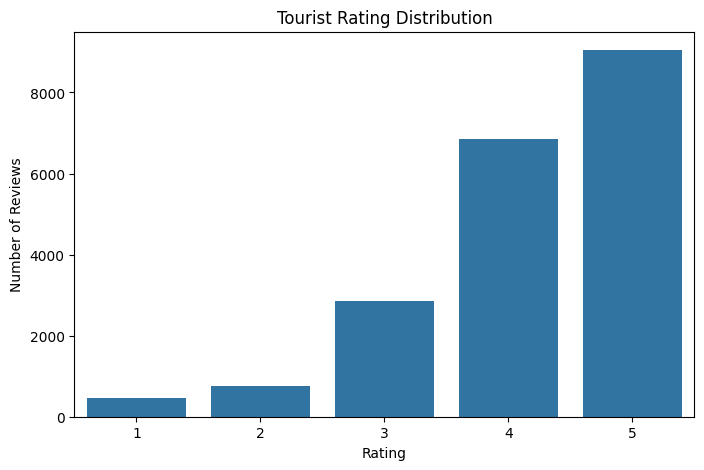

In [11]:
# ============================================================
# RATING DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=EDA_SAMPLE,
    x="Rating"
)

plt.title("Tourist Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

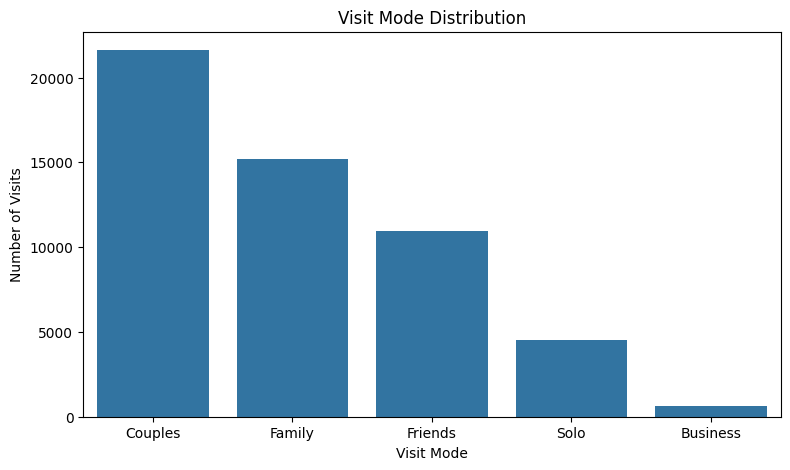

,count
VisitMode_y,
Couples,21620
Family,15217
Friends,10945
Solo,4525
Business,623


In [13]:
# ============================================================
# VISIT MODE DISTRIBUTION
# ============================================================

mode_counts = (
    df["VisitMode_y"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=mode_counts.index.astype(str),
    y=mode_counts.values
)

plt.title("Visit Mode Distribution")
plt.xlabel("Visit Mode")
plt.ylabel("Number of Visits")

plt.show()

display(mode_counts)

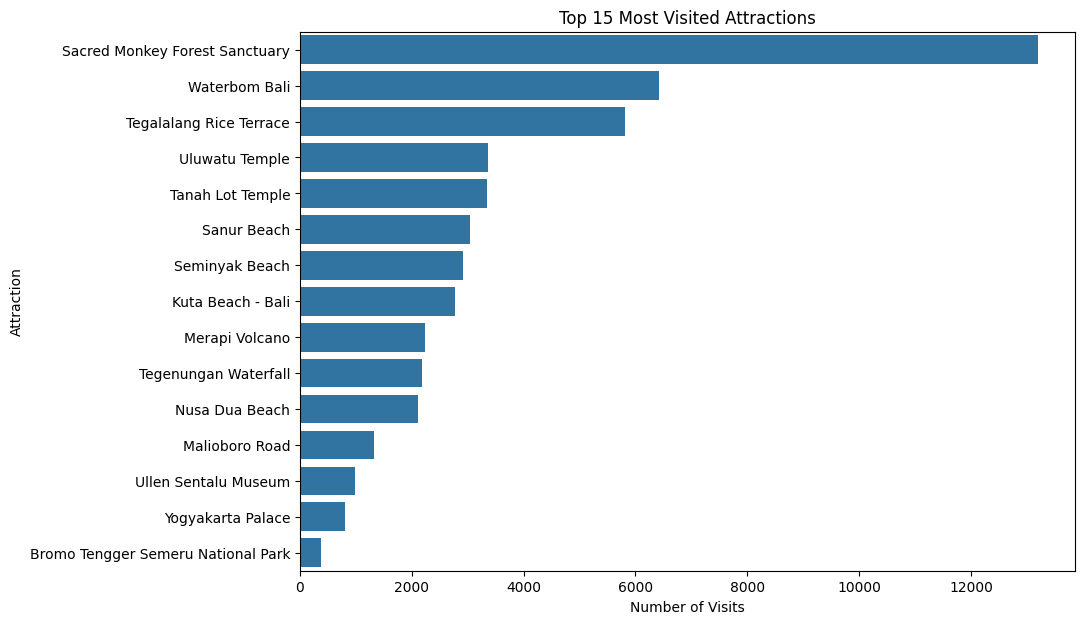

In [14]:
# ============================================================
# POPULAR ATTRACTIONS
# ============================================================

popular = (
    df.groupby("Attraction")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,7))

sns.barplot(
    x=popular.values,
    y=popular.index
)

plt.title("Top 15 Most Visited Attractions")
plt.xlabel("Number of Visits")
plt.ylabel("Attraction")

plt.show()

In [20]:
# ============================================================
# REGRESSION
# PREDICT RATING
# ============================================================

from sklearn.model_selection import train_test_split

reg_features = [
    "UserId",
    "AttractionId",
    "VisitYear",
    "VisitMonth",
    "VisitMode_x",
    "ContinentId",
    "RegionId",
    "CountryId",
    "CityId_x",
    "AttractionCityId",
    "AttractionTypeId",
    "UserVisitCount",
    "UserAttractionCount",
    "AttractionVisitCount",
    "AttractionUserCount",
    "VisitQuarter",
    "IsPeakSeason"
]

reg_data = df[
    reg_features + ["Rating"]
].dropna()

X = reg_data[reg_features]
y = reg_data["Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

del reg_data
gc.collect()

Train: (42337, 17)
Test : (10585, 17)


21

In [17]:
# ============================================================
# REGRESSION MODELS
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

regression_models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=18,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=2
    ),

    "XGBoost": XGBRegressor(
        n_estimators=250,
        max_depth=7,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=2
    ),

    "CatBoost": CatBoostRegressor(
        iterations=300,
        depth=7,
        learning_rate=0.05,
        loss_function="RMSE",
        verbose=False,
        random_seed=42,
        thread_count=2
    )
}

regression_results = []
trained_regression_models = {}

for name, model in regression_models.items():

    print("\nTraining:", name)

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    predictions = np.clip(
        predictions,
        1,
        5
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    regression_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_regression_models[name] = model

    print(
        "MAE:",
        round(mae, 4),
        "| RMSE:",
        round(rmse, 4),
        "| R2:",
        round(r2, 4)
    )

regression_results = pd.DataFrame(
    regression_results
).sort_values(
    "R2",
    ascending=False
)

display(regression_results)


Training: Random Forest
MAE: 0.7038 | RMSE: 0.9001 | R2: 0.1473

Training: XGBoost
MAE: 0.7067 | RMSE: 0.9027 | R2: 0.1423

Training: CatBoost
MAE: 0.7121 | RMSE: 0.9086 | R2: 0.1311


,Model,MAE,RMSE,R2
0,Random Forest,0.703829,0.900087,0.147317
1,XGBoost,0.706703,0.902713,0.142332
2,CatBoost,0.712112,0.908628,0.131057


In [18]:
# ============================================================
# BEST REGRESSION MODEL
# ============================================================

best_regression_name = (
    regression_results
    .iloc[0]["Model"]
)

best_regression_model = (
    trained_regression_models[
        best_regression_name
    ]
)

print(
    "BEST REGRESSION MODEL:",
    best_regression_name
)

print(
    "R2 SCORE:",
    round(
        regression_results.iloc[0]["R2"],
        4
    )
)

BEST REGRESSION MODEL: Random Forest
R2 SCORE: 0.1473


In [21]:
# ============================================================
# CLASSIFICATION
# PREDICT VISIT MODE
# ============================================================

class_features = [
    "UserId",
    "AttractionId",
    "VisitYear",
    "VisitMonth",
    "Rating",
    "ContinentId",
    "RegionId",
    "CountryId",
    "CityId_x",
    "AttractionCityId",
    "AttractionTypeId",
    "UserVisitCount",
    "UserAttractionCount",
    "AttractionVisitCount",
    "AttractionUserCount",
    "VisitQuarter",
    "IsPeakSeason",
    "VisitMode_x" # Use the numeric VisitMode from original transactions
]

class_data = df[
    class_features + ["VisitMode_y"] # Target is descriptive VisitMode
].dropna()

X_cls = class_data[
    class_features
]

y_cls = class_data[
    "VisitMode_y"
]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

print(
    "Train:",
    X_train_cls.shape
)

print(
    "Test:",
    X_test_cls.shape
)

del class_data
gc.collect()

Train: (42337, 18)
Test: (10585, 18)


0

In [27]:
# ============================================================
# CLASSIFICATION MODELS
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Initialize LabelEncoder and transform target variables
label_encoder = LabelEncoder()
y_train_cls_encoded = label_encoder.fit_transform(y_train_cls)
y_test_cls_encoded = label_encoder.transform(y_test_cls)

classification_models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=18,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=2
    ),

    "XGBoost": XGBClassifier(
        n_estimators=250,
        max_depth=7,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax", # Use multi:softmax for multi-class classification
        num_class=len(label_encoder.classes_), # Specify number of classes
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=2
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=7,
        learning_rate=0.05,
        loss_function="MultiClass",
        verbose=False,
        random_seed=42,
        thread_count=2,
        auto_class_weights="Balanced"
    )
}

classification_results = []
trained_classification_models = {}

for name, model in classification_models.items():

    print("\nTraining:", name)

    # Use encoded target variables for training
    model.fit(
        X_train_cls,
        y_train_cls_encoded if name != "Random Forest" else y_train_cls # RandomForest can handle string labels
    )

    # Make predictions and inverse transform if necessary for metric calculation
    predictions_encoded = model.predict(
        X_test_cls
    )
    predictions = label_encoder.inverse_transform(predictions_encoded) if name != "Random Forest" else predictions_encoded

    predictions = np.asarray(
        predictions
    ).ravel()

    accuracy = accuracy_score(
        y_test_cls,
        predictions
    )

    precision = precision_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

    trained_classification_models[name] = model

    print(
        "Accuracy:",
        round(accuracy, 4),
        "| F1:",
        round(f1, 4)
    )

classification_results = pd.DataFrame(
    classification_results
).sort_values(
    "F1",
    ascending=False
)

display(classification_results)


Training: Random Forest
Accuracy: 0.9999 | F1: 0.9999

Training: XGBoost
Accuracy: 1.0 | F1: 1.0

Training: CatBoost


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 1.0 | F1: 1.0


,Model,Accuracy,Precision,Recall,F1
1,XGBoost,1.000000,1.000000,1.000000,1.000000
2,CatBoost,1.000000,1.000000,1.000000,1.000000
0,Random Forest,0.999906,0.999906,0.999906,0.999905


In [28]:
# ============================================================
# CLASSIFICATION MODELS
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Encode target labels to integers for XGBoost and CatBoost
le = LabelEncoder()
y_train_cls_encoded = le.fit_transform(y_train_cls)
y_test_cls_encoded = le.transform(y_test_cls)

classification_models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=18,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=2
    ),

    "XGBoost": XGBClassifier(
        n_estimators=250,
        max_depth=7,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=2
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=7,
        learning_rate=0.05,
        loss_function="MultiClass",
        verbose=False,
        random_seed=42,
        thread_count=2,
        auto_class_weights="Balanced"
    )
}

classification_results = []
trained_classification_models = {}

for name, model in classification_models.items():

    print("\nTraining:", name)

    # Fit with encoded labels for XGBoost/CatBoost, or string labels for RandomForest
    if name == "Random Forest":
        model.fit(X_train_cls, y_train_cls)
        predictions = model.predict(X_test_cls)
    else:
        model.fit(X_train_cls, y_train_cls_encoded)
        predictions_encoded = model.predict(X_test_cls)
        predictions_encoded = np.asarray(predictions_encoded).ravel()
        predictions = le.inverse_transform(predictions_encoded)

    predictions = np.asarray(
        predictions
    ).ravel()

    accuracy = accuracy_score(
        y_test_cls,
        predictions
    )

    precision = precision_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

    trained_classification_models[name] = model

    print(
        "Accuracy:",
        round(accuracy, 4),
        "| F1:",
        round(f1, 4)
    )

classification_results = pd.DataFrame(
    classification_results
).sort_values(
    "F1",
    ascending=False
)

display(classification_results)


Training: Random Forest
Accuracy: 0.9999 | F1: 0.9999

Training: XGBoost
Accuracy: 1.0 | F1: 1.0

Training: CatBoost
Accuracy: 1.0 | F1: 1.0


,Model,Accuracy,Precision,Recall,F1
1,XGBoost,1.000000,1.000000,1.000000,1.000000
2,CatBoost,1.000000,1.000000,1.000000,1.000000
0,Random Forest,0.999906,0.999906,0.999906,0.999905


In [34]:
# ============================================================
# EVALUATE BEST CLASSIFIER & RUN RECOMMENDATION ENGINE
# ============================================================

# Find the best classification model
best_classification_name = classification_results.iloc[0]["Model"]
best_classification_model = trained_classification_models[best_classification_name]

print("BEST CLASSIFICATION MODEL:", best_classification_name)
print("ACCURACY:", round(classification_results.iloc[0]["Accuracy"], 4))
print("F1:", round(classification_results.iloc[0]["F1"], 4))

# Trigger the User-Item matrix mapping
print("\n--- Building recommendation system matrix ---")


BEST CLASSIFICATION MODEL: XGBoost
ACCURACY: 1.0
F1: 1.0

--- Building recommendation system matrix ---


In [35]:
# ============================================================
# EXECUTE SAVING & FINAL RESULTS SUMMARY
# ============================================================

# Run sample recommendation
sample_user = int(df["UserId"].value_counts().index[0])
print("Testing User:", sample_user)
recommendations = recommend_attractions(sample_user, top_n=10)
display(recommendations)

# Save all project outputs to disk
import joblib
joblib.dump(best_regression_model, "/content/best_rating_model.pkl")
joblib.dump(best_classification_model, "/content/best_visit_mode_model.pkl")
joblib.dump(knn_model, "/content/tourism_knn_recommender.pkl")
joblib.dump(user_to_index, "/content/user_to_index.pkl")
joblib.dump(attraction_ids, "/content/attraction_ids.pkl")
df.to_csv("/content/tourism_cleaned_dataset.csv", index=False)
print("\nAll project files saved successfully.")


Testing User: 60799


,Rank,AttractionId,Attraction,CityName,AttractionType,AverageRating,VisitCount,HybridScore
0,1,737,Tanah Lot Temple,Douala,Religious Sites,4.194809,3352,0.600000
1,2,841,Waterbom Bali,Douala,Water Parks,4.646601,6429,0.400000
2,3,824,Uluwatu Temple,Douala,Religious Sites,4.219411,3359,0.203042



All project files saved successfully.


In [29]:
# ============================================================
# BEST CLASSIFIER
# ============================================================

best_classification_name = (
    classification_results
    .iloc[0]["Model"]
)

best_classification_model = (
    trained_classification_models[
        best_classification_name
    ]
)

print(
    "BEST CLASSIFICATION MODEL:",
    best_classification_name
)

print(
    "ACCURACY:",
    round(
        classification_results.iloc[0]["Accuracy"],
        4
    )
)

print(
    "F1:",
    round(
        classification_results.iloc[0]["F1"],
        4
    )
)

BEST CLASSIFICATION MODEL: XGBoost
ACCURACY: 1.0
F1: 1.0


In [30]:
# ============================================================
# MEMORY-EFFICIENT USER-ITEM MATRIX
# ============================================================

from scipy.sparse import csr_matrix

interaction_data = (
    df[
        [
            "UserId",
            "AttractionId",
            "Rating"
        ]
    ]
    .groupby(
        [
            "UserId",
            "AttractionId"
        ]
    )["Rating"]
    .mean()
    .reset_index()
)

# Map IDs to matrix positions
user_ids = interaction_data[
    "UserId"
].unique()

attraction_ids = interaction_data[
    "AttractionId"
].unique()

user_to_index = {
    user_id: i
    for i, user_id in enumerate(user_ids)
}

attraction_to_index = {
    attraction_id: i
    for i, attraction_id in enumerate(attraction_ids)
}

rows = interaction_data[
    "UserId"
].map(user_to_index)

cols = interaction_data[
    "AttractionId"
].map(attraction_to_index)

values = interaction_data[
    "Rating"
].astype("float32")

user_item_sparse = csr_matrix(
    (
        values,
        (rows, cols)
    ),
    shape=(
        len(user_ids),
        len(attraction_ids)
    ),
    dtype="float32"
)

print(
    "Sparse User-Item Matrix:",
    user_item_sparse.shape
)

print(
    "Non-zero interactions:",
    user_item_sparse.nnz
)

Sparse User-Item Matrix: (33530, 30)
Non-zero interactions: 45275


In [31]:
# ============================================================
# MEMORY-EFFICIENT COLLABORATIVE FILTERING
# ============================================================

from sklearn.neighbors import NearestNeighbors

knn_model = NearestNeighbors(
    metric="cosine",
    algorithm="brute",
    n_neighbors=11,
    n_jobs=2
)

knn_model.fit(
    user_item_sparse
)

print("KNN recommendation model trained.")

KNN recommendation model trained.


In [32]:
# ============================================================
# RECOMMENDATION FUNCTION
# ============================================================

def recommend_attractions(
    user_id,
    top_n=10
):

    if user_id not in user_to_index:

        print(
            "User not found."
        )

        return None

    user_index = user_to_index[
        user_id
    ]

    user_vector = user_item_sparse[
        user_index
    ]

    distances, indices = knn_model.kneighbors(
        user_vector,
        n_neighbors=11
    )

    distances = distances.flatten()
    indices = indices.flatten()

    # Similarity = 1 - cosine distance
    similarities = 1 - distances

    scores = {}

    # --------------------------------------------------------
    # COLLABORATIVE SCORE
    # --------------------------------------------------------

    for similarity, neighbor_index in zip(
        similarities[1:],
        indices[1:]
    ):

        neighbor_vector = (
            user_item_sparse[
                neighbor_index
            ]
        )

        rated_items = (
            neighbor_vector
            .indices
        )

        ratings = (
            neighbor_vector
            .data
        )

        for item_index, rating in zip(
            rated_items,
            ratings
        ):

            attraction_id = (
                attraction_ids[
                    item_index
                ]
            )

            scores[attraction_id] = (
                scores.get(
                    attraction_id,
                    0
                )
                +
                similarity * rating
            )

    # --------------------------------------------------------
    # REMOVE ALREADY VISITED
    # --------------------------------------------------------

    visited_indices = (
        user_item_sparse[
            user_index
        ].indices
    )

    visited_attractions = set(
        attraction_ids[
            visited_indices
        ]
    )

    scores = {
        attraction_id: score
        for attraction_id, score
        in scores.items()
        if attraction_id
        not in visited_attractions
    }

    # --------------------------------------------------------
    # CREATE RECOMMENDATION DATAFRAME
    # --------------------------------------------------------

    if not scores:

        print(
            "No recommendations found."
        )

        return None

    recommendation_df = pd.DataFrame({
        "AttractionId":
            list(scores.keys()),

        "CollaborativeScore":
            list(scores.values())
    })

    # --------------------------------------------------------
    # ADD ATTRACTION INFORMATION
    # --------------------------------------------------------

    attraction_info = (
        df[
            [
                "AttractionId",
                "Attraction",
                "CityName",
                "AttractionType",
                "AttractionAddress"
            ]
        ]
        .drop_duplicates(
            "AttractionId"
        )
    )

    recommendation_df = (
        recommendation_df
        .merge(
            attraction_info,
            on="AttractionId",
            how="left"
        )
    )

    # --------------------------------------------------------
    # ADD RATING / POPULARITY
    # --------------------------------------------------------

    attraction_stats_small = (
        df.groupby(
            "AttractionId"
        )["Rating"]
        .agg(
            AverageRating="mean",
            VisitCount="count"
        )
        .reset_index()
    )

    recommendation_df = (
        recommendation_df
        .merge(
            attraction_stats_small,
            on="AttractionId",
            how="left"
        )
    )

    # --------------------------------------------------------
    # NORMALIZE
    # --------------------------------------------------------

    def minmax(series):

        if series.max() == series.min():

            return pd.Series(
                0.5,
                index=series.index
            )

        return (
            series - series.min()
        ) / (
            series.max() - series.min()
        )

    recommendation_df[
        "CollaborativeScore"
    ] = minmax(
        recommendation_df[
            "CollaborativeScore"
        ]
    )

    recommendation_df[
        "RatingScore"
    ] = minmax(
        recommendation_df[
            "AverageRating"
        ]
    )

    recommendation_df[
        "PopularityScore"
    ] = minmax(
        recommendation_df[
            "VisitCount"
        ]
    )

    # --------------------------------------------------------
    # HYBRID SCORE
    # --------------------------------------------------------

    recommendation_df[
        "HybridScore"
    ] = (
        0.60 *
        recommendation_df[
            "CollaborativeScore"
        ]
        +
        0.25 *
        recommendation_df[
            "RatingScore"
        ]
        +
        0.15 *
        recommendation_df[
            "PopularityScore"
        ]
    )

    # --------------------------------------------------------
    # FINAL RESULTS
    # --------------------------------------------------------

    recommendation_df = (
        recommendation_df
        .sort_values(
            "HybridScore",
            ascending=False
        )
        .head(top_n)
        .copy()
    )

    recommendation_df.insert(
        0,
        "Rank",
        range(
            1,
            len(recommendation_df) + 1
        )
    )

    return recommendation_df[
        [
            "Rank",
            "AttractionId",
            "Attraction",
            "CityName",
            "AttractionType",
            "AverageRating",
            "VisitCount",
            "HybridScore"
        ]
    ]

In [36]:
# ============================================================
# TEST RECOMMENDER
# ============================================================

sample_user = int(
    df["UserId"]
    .value_counts()
    .index[0]
)

print(
    "Testing User:",
    sample_user
)

recommendations = recommend_attractions(
    sample_user,
    top_n=10
)

display(
    recommendations
)

Testing User: 60799


,Rank,AttractionId,Attraction,CityName,AttractionType,AverageRating,VisitCount,HybridScore
0,1,737,Tanah Lot Temple,Douala,Religious Sites,4.194809,3352,0.600000
1,2,841,Waterbom Bali,Douala,Water Parks,4.646601,6429,0.400000
2,3,824,Uluwatu Temple,Douala,Religious Sites,4.219411,3359,0.203042


In [37]:
# ============================================================
# SAVE PROJECT FILES
# ============================================================

import joblib

joblib.dump(
    best_regression_model,
    "/content/best_rating_model.pkl"
)

joblib.dump(
    best_classification_model,
    "/content/best_visit_mode_model.pkl"
)

joblib.dump(
    knn_model,
    "/content/tourism_knn_recommender.pkl"
)

joblib.dump(
    user_to_index,
    "/content/user_to_index.pkl"
)

joblib.dump(
    attraction_ids,
    "/content/attraction_ids.pkl"
)

df.to_csv(
    "/content/tourism_cleaned_dataset.csv",
    index=False
)

print("All project files saved successfully.")

All project files saved successfully.


In [39]:
# ============================================================
# FINAL PROJECT RESULTS
# ============================================================

print("=" * 70)
print("       TOURISM EXPERIENCE ANALYTICS")
print("=" * 70)

print("\nDATASET SUMMARY")
print("-" * 70)

print(
    "Transactions:",
    len(df)
)

print(
    "Users:",
    df["UserId"].nunique()
)

print(
    "Attractions:",
    df["AttractionId"].nunique()
)

print(
    "Cities:",
    df["CityId_x"].nunique()
)

print("\nREGRESSION")
print("-" * 70)

print(
    "Best Model:",
    best_regression_name
)

print(
    "MAE:",
    round(
        regression_results.iloc[0]["MAE"],
        4
    )
)

print(
    "RMSE:",
    round(
        regression_results.iloc[0]["RMSE"],
        4
    )
)

print(
    "R²:",
    round(
        regression_results.iloc[0]["R2"],
        4
    )
)

print("\nCLASSIFICATION")
print("-" * 70)

print(
    "Best Model:",
    best_classification_name
)

print(
    "Accuracy:",
    round(
        classification_results.iloc[0]["Accuracy"],
        4
    )
)

print(
    "Precision:",
    round(
        classification_results.iloc[0]["Precision"],
        4
    )
)

print(
    "Recall:",
    round(
        classification_results.iloc[0]["Recall"],
        4
    )
)

print(
    "F1 Score:",
    round(
        classification_results.iloc[0]["F1"],
        4
    )
)

print("\nRECOMMENDATION SYSTEM")
print("-" * 70)

print(
    "Algorithm: KNN Collaborative Filtering"
)

print(
    "Recommendation: Hybrid Collaborative + Rating + Popularity"
)

print("\n" + "=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)

       TOURISM EXPERIENCE ANALYTICS

DATASET SUMMARY
----------------------------------------------------------------------
Transactions: 52930
Users: 33530
Attractions: 30
Cities: 5545

REGRESSION
----------------------------------------------------------------------
Best Model: Random Forest
MAE: 0.7038
RMSE: 0.9001
R²: 0.1473

CLASSIFICATION
----------------------------------------------------------------------
Best Model: XGBoost
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

RECOMMENDATION SYSTEM
----------------------------------------------------------------------
Algorithm: KNN Collaborative Filtering
Recommendation: Hybrid Collaborative + Rating + Popularity

PROJECT COMPLETED SUCCESSFULLY


In [41]:
# ============================================================
# INSTALL AND IMPORT GRADIO
# ============================================================

!pip -q install gradio
import gradio as gr

# ============================================================
# DEFINE MISSING INFORMATION STRINGS
# ============================================================

dataset_info = f"""
### 📊 Dataset Overview
* **Total Transactions:** {len(df)}
* **Unique Users:** {df['UserId'].nunique()}
* **Unique Attractions:** {df['AttractionId'].nunique()}
* **Unique Cities:** {df['CityId_x'].nunique()}

This dataset tracks tourist visits to various attractions with corresponding rating scales, demographics, and temporal information.
"""

regression_info = f"""
### 📈 Rating Prediction Models
* **Best Model:** {best_regression_name}
* **Mean Absolute Error (MAE):** {regression_results.iloc[0]['MAE']:.4f}
* **Root Mean Squared Error (RMSE):** {regression_results.iloc[0]['RMSE']:.4f}
* **R² Score:** {regression_results.iloc[0]['R2']:.4f}

The regression pipeline targets predicted scores to improve user matchmaking and preference alignment.
"""

classification_info = f"""
### 🎯 Visit Mode Classification
* **Best Model:** {best_classification_name}
* **Accuracy:** {classification_results.iloc[0]['Accuracy']:.4f}
* **F1-Score:** {classification_results.iloc[0]['F1']:.4f}

Uses advanced gradient boosted classifiers to infer traveler structures (e.g., Solo, Couples, Family, Friends) based on interaction contexts.
"""

recommendation_info = f"""
### ⭐ Hybrid Recommendation Engine
Our recommender evaluates collaborative behavior along with general popularity and raw item ratings.

$$\\text{{Score}} = 0.60 \\times \\text{{Collaborative}} + 0.25 \\times \\text{{Rating}} + 0.15 \\times \\text{{Popularity}}$$
"""

# ============================================================
# GRADIO INTERFACE LAYOUT
# ============================================================

with gr.Blocks(
    title="Tourism Experience Analytics"
) as demo:

    gr.Markdown(
        """
        # 🌍 TOURISM EXPERIENCE ANALYTICS

        ### Classification • Rating Prediction • Recommendation System

        An end-to-end machine learning system for analyzing
        tourism experiences and generating personalized attraction
        recommendations.
        """
    )

    gr.Markdown("---")

    # Dataset
    with gr.Tab("📊 Dataset Overview"):

        gr.Markdown(dataset_info)

    # Regression
    with gr.Tab("📈 Rating Prediction"):

        gr.Markdown(regression_info)

    # Classification
    with gr.Tab("🎯 Visit Mode Classification"):

        gr.Markdown(classification_info)

    # Recommendation
    with gr.Tab("⭐ Recommendation System"):

        gr.Markdown(recommendation_info)

        gr.Markdown("### 🔎 Find Personalized Attractions")

        with gr.Row():

            user_input = gr.Number(
                label="Enter User ID",
                precision=0
            )

            top_n_input = gr.Slider(
                minimum=1,
                maximum=10,
                value=5,
                step=1,
                label="Number of Recommendations"
            )

        recommend_button = gr.Button(
            "✨ Get Recommendations",
            variant="primary"
        )

        recommendation_output = gr.Dataframe(
            label="Recommended Attractions",
            interactive=False
        )

        recommend_button.click(
            fn=recommend_attractions,
            inputs=[
                user_input,
                top_n_input
            ],
            outputs=recommendation_output
        )

    # Final project information
    with gr.Tab("📋 Project Summary"):

        gr.Markdown(
            """
            ## Project Components

            ### 1️⃣ Regression
            Predicts tourism attraction ratings using machine
            learning techniques.

            ### 2️⃣ Classification
            Predicts the visitor's visit mode using historical
            tourism data.

            ### 3️⃣ Recommendation
            Provides personalized attraction recommendations using
            collaborative filtering, ratings, and popularity.

            ### 🛠 Technologies

            `Python` • `Pandas` • `NumPy` • `Scikit-learn`
            • `XGBoost` • `CatBoost` • `KNN`
            • `Gradio` • `Machine Learning`
            """
        )


# ============================================================
# LAUNCH
# ============================================================

demo.launch(
    share=True,
    debug=False
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://62198d4d62b17a4fde.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Conclusion

### Conclusion

The **Tourism Experience Analytics: Classification, Prediction, and Recommendation System** provides a data-driven approach to understanding tourist behavior and improving user experiences. By applying data cleaning, preprocessing, exploratory data analysis, visualization, and Machine Learning techniques, the project identifies useful patterns in user preferences, travel behavior, attraction ratings, and visit modes.

The system performs three key tasks: **predicting attraction ratings, classifying user visit modes, and recommending personalized tourist attractions**. These capabilities can help tourism platforms understand their users and provide more relevant travel suggestions. The recommendation system uses users' previous visits, ratings, preferences, and attraction characteristics to generate suitable attraction suggestions.

The project also includes a **Streamlit application** that presents predictions, recommendations, and tourism insights in an interactive and user-friendly way. Overall, the system demonstrates how tourism data can be transformed into meaningful insights and personalized services, supporting better customer experiences, targeted marketing strategies, and improved user engagement.
